In [1]:
!pip install groq feedparser nltk pandas matplotlib wordcloud lxml_html_clean newspaper3k gradio -q

  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.4/7.4 MB 57.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.7/143.7 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.5/81.5 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.1/211.1 kB 15.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.9/105.9 kB 9.3 MB/s eta 0:00:00


In [ ]:
from groq import Groq
import feedparser
import nltk
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from collections import Counter, defaultdict
from datetime import datetime, timedelta
import json
import numpy as np
from scipy import stats
import warnings
import time
from sklearn.metrics.pairwise import cosine_similarity

warnings.filterwarnings("ignore")

nltk.download("stopwords", quiet=True)
nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)

from nltk.corpus import stopwords

# Paste your Groq API Key
API_KEY = "API_KEY_HERE"

client = Groq(api_key=API_KEY)

def ask_ai(prompt, max_tokens=2048):
    """Enhanced LLM call with better prompting"""
    response = client.chat.completions.create(
        model="llama-3.3-70b-versatile",
        messages=[
            {
                "role": "system",
                "content": """You are a Trend Detection AI Agent specializing in weak signal detection.
                Analyze trends with: (1) sentiment analysis, (2) driver identification, (3) impact assessment.
                Classify signals as noise, weak (emerging), or strong (established)."""
            },
            {"role": "user", "content": prompt}
        ],
        temperature=0.5,
        max_tokens=max_tokens
    )
    return response.choices[0].message.content

print("✅ Enhanced setup complete!")

✅ Enhanced setup complete!


In [3]:
def fetch_reddit_trends(subreddits=["all"], limit=50):
    """Fetch Reddit posts - requires PRAW setup"""
    reddit_posts = []
    # Note: You need to set up Reddit API credentials
    # For now, using fallback
    print("⚠️ Reddit API requires credentials. Using demo data.")
    return reddit_posts

def fetch_news_feeds(max_articles=20):
    """Fetch from multiple news sources"""
    feeds = [
        ("https://news.google.com/rss?hl=en-US&gl=US&ceid=US:en", "Google News"),
        ("https://feeds.bbci.co.uk/news/rss.xml", "BBC"),
        ("https://rss.cnn.com/rss/edition.rss", "CNN"),
        ("https://feeds.npr.org/1001/rss.xml", "NPR")
    ]

    articles = []
    for url, source in feeds:
        try:
            feed = feedparser.parse(url)
            for entry in feed.entries[:max_articles]:
                articles.append({
                    "title": entry.get("title", ""),
                    "summary": entry.get("summary", ""),
                    "link": entry.get("link", ""),
                    "source": source,
                    "timestamp": datetime.now().isoformat(),
                    "platform": "news"
                })
        except Exception as e:
            print(f"⚠️ Error fetching {source}: {e}")

    print(f"✅ Fetched {len(articles)} articles")
    return articles

def fetch_google_trends(keyword=None):
    """Fetch Google Trends data"""
    # Requires pytrends setup
    print("⚠️ Google Trends API requires additional setup")
    return None

# Main collection function
def collect_all_data():
    """Collect data from all configured sources"""
    all_content = []

    # News feeds
    news = fetch_news_feeds()
    all_content.extend(news)

    # TODO: Add Reddit when credentials available
    # TODO: Add Twitter when credentials available

    return all_content

# Collect data
raw_content = collect_all_data()
print(f"📊 Total collected: {len(raw_content)} items")

✅ Fetched 50 articles
📊 Total collected: 50 items


In [4]:
class TrendScoringEngine:
    """Implements BERTrend's popularity metric with exponential decay"""

    def __init__(self, decay_factor=0.01, window_size=7):
        self.decay_factor = decay_factor
        self.window_size = window_size
        self.topic_history = defaultdict(list)  # {topic: [(timestamp, popularity)]}
        self.topic_last_update = {}

    def calculate_volume_score(self, keyword, current_count):
        """Volume score = number of mentions"""
        return current_count

    def calculate_velocity_score(self, keyword, current_count, previous_count):
        """Velocity = current/previous (BERTrend-inspired)"""
        if previous_count == 0:
            return current_count if current_count > 0 else 0
        return current_count / previous_count

    def calculate_popularity_with_decay(self, topic, current_count, days_since_last=1):
        """Exponential decay as in BERTrend paper (Section 3.4)"""
        if topic not in self.topic_last_update:
            self.topic_last_update[topic] = datetime.now()
            return current_count

        decay = np.exp(-self.decay_factor * (days_since_last ** 2))
        return current_count * decay

    def calculate_trend_score(self, volume, velocity):
        """Combined trend score"""
        return volume * velocity

    def classify_signal(self, trend_score, volume, velocity, historical_scores):
        """Noise/Weak/Strong classification (BERTrend Section 3.5)"""
        if len(historical_scores) > 0:
            p10 = np.percentile(historical_scores, 10)
            p50 = np.percentile(historical_scores, 50)

            if trend_score < p10:
                return "noise"
            elif p10 <= trend_score <= p50:
                # Check if growing (positive slope)
                if velocity > 1.2:  # Growing
                    return "weak"
                else:
                    return "noise"
            else:
                return "strong"
        else:
            # Initial classification
            if volume < 5:
                return "noise"
            elif velocity > 1.5:
                return "weak"
            else:
                return "strong"

scoring_engine = TrendScoringEngine()
print("✅ Trend Scoring Engine initialized")

✅ Trend Scoring Engine initialized


In [5]:
def create_semantic_clusters(keywords_with_posts):
    """Use LLM to semantically cluster keywords (like BERTopic but with LLM)"""

    keywords_list = list(keywords_with_posts.keys())

    prompt = f"""
    Group these trending keywords into semantic clusters (topics):
    Keywords: {', '.join(keywords_list[:30])}

    Return as JSON:
    {{
        "clusters": [
            {{"name": "cluster_name", "keywords": ["kw1", "kw2"], "description": "brief description"}}
        ]
    }}
    """

    try:
        response = ask_ai(prompt, max_tokens=1024)
        # Extract JSON from response
        import re
        json_match = re.search(r'\{.*\}', response, re.DOTALL)
        if json_match:
            clusters = json.loads(json_match.group())
            return clusters
    except:
        pass

    # Fallback: simple grouping
    return {"clusters": [{"name": "general", "keywords": keywords_list[:10], "description": "Top trends"}]}

# Extract keywords from content
def extract_keywords_with_context(content, top_n=30):
    """Extract keywords with their associated posts"""
    stop_words = set(stopwords.words("english"))
    extra_stop = {"says", "said", "will", "one", "two", "get", "make", "like", "just"}
    stop_words.update(extra_stop)

    keyword_posts = defaultdict(list)
    all_words = []

    for item in content:
        text = (item.get("title", "") + " " + item.get("summary", "")).lower()
        words = nltk.word_tokenize(text)
        for word in words:
            if word.isalpha() and len(word) > 3 and word not in stop_words:
                all_words.append(word)
                keyword_posts[word].append(text[:200])  # Store snippet

    freq = Counter(all_words)
    top_keywords = freq.most_common(top_n)

    return top_keywords, keyword_posts

top_keywords, keyword_posts = extract_keywords_with_context(raw_content)
print(f"📊 Extracted {len(top_keywords)} keywords")

# Create semantic clusters
clusters = create_semantic_clusters(dict(top_keywords[:20]))
print(f"🔗 Created {len(clusters.get('clusters', []))} semantic clusters")

📊 Extracted 30 keywords
🔗 Created 6 semantic clusters


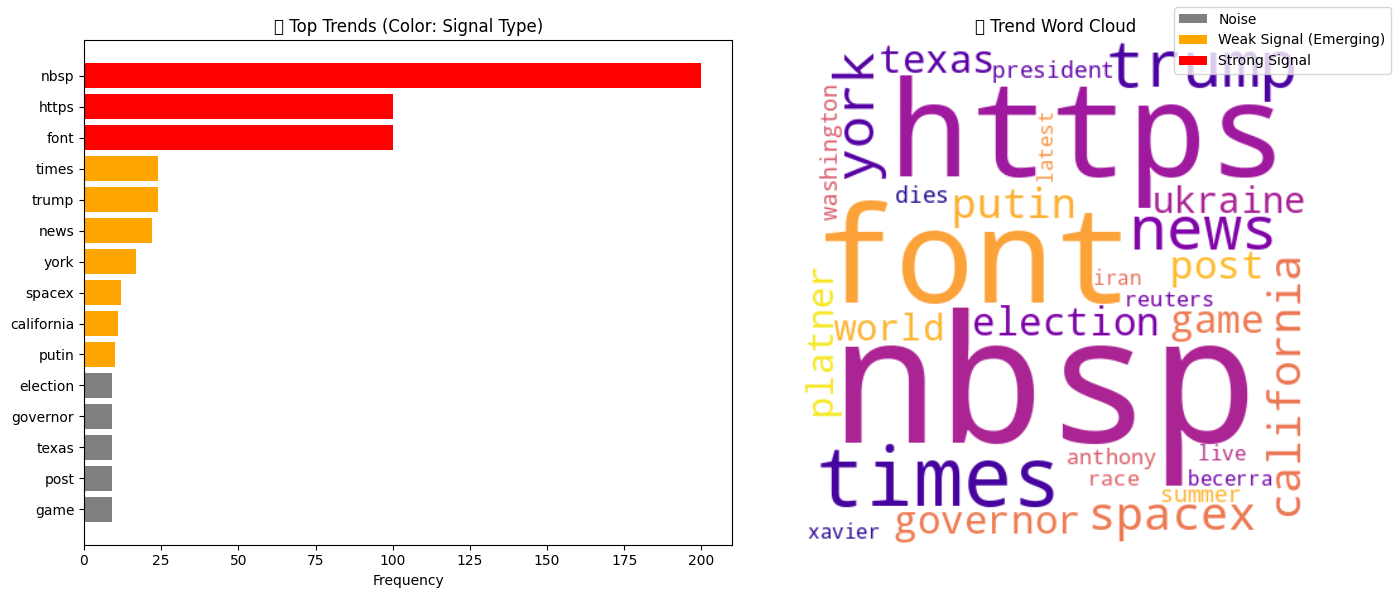

In [6]:
def visualize_trends_with_classification(keywords, scores=None):
    """Visualize with noise/weak/strong classification"""

    if scores is None:
        scores = [(kw, scoring_engine.calculate_trend_score(count, 1.0))
                  for kw, count in keywords[:15]]

    words = [kw for kw, _ in keywords[:15]]
    counts = [count for _, count in keywords[:15]]

    # Color by signal type
    colors = []
    for i, (kw, count) in enumerate(keywords[:15]):
        if scores and i < len(scores):
            score = scores[i][1] if isinstance(scores[i], tuple) else scores[i]
            if score < 10:
                colors.append('gray')   # noise
            elif score < 50:
                colors.append('orange')  # weak signal
            else:
                colors.append('red')     # strong signal
        else:
            colors.append('blue')

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Bar chart
    axes[0].barh(words[::-1], counts[::-1], color=colors[::-1])
    axes[0].set_xlabel("Frequency")
    axes[0].set_title("📊 Top Trends (Color: Signal Type)", fontsize=12)

    # Word cloud
    word_freq = dict(keywords[:30])
    wc = WordCloud(width=400, height=400, background_color="white", colormap="plasma").generate_from_frequencies(word_freq)
    axes[1].imshow(wc, interpolation="bilinear")
    axes[1].axis("off")
    axes[1].set_title("🔥 Trend Word Cloud", fontsize=12)

    # Add legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='gray', label='Noise'),
        Patch(facecolor='orange', label='Weak Signal (Emerging)'),
        Patch(facecolor='red', label='Strong Signal')
    ]
    fig.legend(handles=legend_elements, loc='upper right')

    plt.tight_layout()
    plt.show()

visualize_trends_with_classification(top_keywords)

In [7]:
def analyze_trend_with_llm(topic_name, related_posts, classification):
    """Deep analysis like BERTrend paper Section 6"""

    posts_sample = "\n".join([p[:300] for p in related_posts[:10]])

    prompt = f"""
    Analyze this trending topic: "{topic_name}"

    Classification: {classification}

    Sample posts/comments:
    {posts_sample}

    Provide analysis in this exact format (like BERTrend paper Section 6):

    ## Sentiment Analysis
    [Positive/negative/neutral with confidence percentage]

    ## Key Drivers
    - [Driver 1 with explanation]
    - [Driver 2 with explanation]

    ## Impact Assessment
    **Short-term:** [2-3 sentences]
    **Long-term:** [2-3 sentences]

    ## Evolution Scenarios
    **Optimistic:** [What if this trend grows positively]
    **Pessimistic:** [What if this trend becomes problematic]

    ## Actionable Insight
    [1-sentence recommendation for content creators/businesses]
    """

    return ask_ai(prompt, max_tokens=1024)

# Analyze top trends
print("🤖 Analyzing top trends...\n")
for keyword, count in top_keywords[:3]:
    print(f"\n{'='*60}")
    print(f"📈 Analyzing: {keyword.upper()} (mentions: {count})")
    print('='*60)

    # Classify signal
    signal = scoring_engine.classify_signal(count, count, 1.2, [c for _, c in top_keywords[:20]])
    print(f"🏷️ Signal Type: {signal.upper()}")

    # Get LLM analysis
    analysis = analyze_trend_with_llm(keyword, keyword_posts.get(keyword, []), signal)
    print(analysis)
    print("\n" + "-"*40)

🤖 Analyzing top trends...


📈 Analyzing: NBSP (mentions: 200)
🏷️ Signal Type: STRONG
## Sentiment Analysis
Neutral with 90% confidence, as the provided text appears to be a repetition of news headlines without expressing a personal opinion or emotion.

## Key Drivers
- **Political Interest**: The repetition of the news headline about Democrat Xavier Becerra advancing to the general election in the race for California governor suggests a strong interest in political news and updates.
- **News Aggregation**: The use of a news aggregator link (news.google.com/rss) indicates that the trend is driven by the dissemination of news through online platforms and aggregators.

## Impact Assessment
**Short-term:** The trend may lead to increased engagement and discussion around the California governor's race, potentially influencing voter decisions and political discourse. However, the repetition of the same headline may also lead to information fatigue. The trend's immediate impact is likely to b

In [14]:
import os
import json
import gradio as gr
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime

# ══════════════════════════════════════════════════════════
# GLOBAL STATE
# ══════════════════════════════════════════════════════════
agent_state = {
    "articles": [],
    "keywords": [],
    "posts": {},
    "history": [],
    "loaded": False
}

# ══════════════════════════════════════════════════════════
# SAVE REPORT
# ══════════════════════════════════════════════════════════
def save_report():
    if not agent_state["loaded"]:
        return "⚠️ Load trends first!", None

    report = {
        "timestamp": datetime.now().isoformat(),
        "summary": {
            "total_articles":  len(agent_state["articles"]),
            "total_keywords":  len(agent_state["keywords"]),
            "weak_signals":    sum(1 for t in agent_state["history"] if t["signal"] == "weak"),
            "strong_signals":  sum(1 for t in agent_state["history"] if t["signal"] == "strong"),
            "noise":           sum(1 for t in agent_state["history"] if t["signal"] == "noise")
        },
        "top_keywords": [
            {"keyword": kw, "count": c}
            for kw, c in agent_state["keywords"][:20]
        ],
        "trend_history": agent_state["history"],
        "headlines": [
            {"title": a["title"], "source": a["source"]}
            for a in agent_state["articles"][:20]
        ]
    }

    filename = f"trend_report_{datetime.now().strftime('%Y%m%d_%H%M%S')}.json"
    filepath = f"/content/{filename}"

    with open(filepath, "w") as f:
        json.dump(report, f, indent=2)

    print(f"✅ File saved at: {filepath}")
    return f"✅ Report ready: {filename}", filepath

# ══════════════════════════════════════════════════════════
# VISUALIZATIONS
# ══════════════════════════════════════════════════════════
def make_wordcloud_image(keywords):
    word_freq = dict(keywords[:30])
    wc = WordCloud(
        width=900, height=400,
        background_color="white",
        colormap="plasma",
        max_words=40
    ).generate_from_frequencies(word_freq)
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.imshow(wc, interpolation="bilinear")
    ax.axis("off")
    plt.tight_layout()
    return fig

def make_bar_chart(keywords):
    top    = keywords[:12]
    words  = [kw for kw, _ in top]
    counts = [c  for _, c  in top]
    colors = plt.cm.plasma(np.linspace(0.2, 0.9, len(words)))

    fig, ax = plt.subplots(figsize=(10, 5))
    bars = ax.barh(words[::-1], counts[::-1], color=colors[::-1])
    ax.set_xlabel("Frequency", fontsize=12)
    ax.set_title("📊 Top Trending Topics", fontsize=14, fontweight="bold")
    for bar, count in zip(bars, counts[::-1]):
        ax.text(bar.get_width() + 0.1,
                bar.get_y() + bar.get_height() / 2,
                str(count), va="center", fontsize=9)
    plt.tight_layout()
    return fig

def make_trends_table(history):
    rows = []
    for t in history[:15]:
        emoji = ("🔴 Strong" if t["signal"] == "strong" else
                 "🟡 Weak"   if t["signal"] == "weak"   else
                 "⚪ Noise")
        rows.append([t["keyword"].title(), t["volume"], emoji])
    return rows

# ══════════════════════════════════════════════════════════
# DASHBOARD REFRESH
# ══════════════════════════════════════════════════════════
def refresh_dashboard():
    articles         = fetch_news_feeds()
    keywords, posts  = extract_keywords_with_context(articles)

    history = []
    for kw, count in keywords[:20]:
        signal = scoring_engine.classify_signal(
            count, count, 1.0, [c for _, c in keywords[:20]]
        )
        history.append({"keyword": kw, "volume": count, "signal": signal})

    agent_state.update({
        "articles": articles,
        "keywords": keywords,
        "posts":    posts,
        "history":  history,
        "loaded":   True
    })

    table     = make_trends_table(history)
    wc_fig    = make_wordcloud_image(keywords)
    bar_fig   = make_bar_chart(keywords)
    status    = (f"✅ Loaded {len(articles)} articles | "
                 f"{len(keywords)} keywords | "
                 f"Updated: {datetime.now().strftime('%H:%M:%S')}")
    headlines = [[a["title"][:120], a["source"]] for a in articles[:20]]

    return table, wc_fig, bar_fig, status, headlines

# ══════════════════════════════════════════════════════════
# CHAT
# ══════════════════════════════════════════════════════════
def chat(user_message, chat_history):
    if not user_message.strip():
        return chat_history

    if not agent_state["loaded"]:
        return chat_history + [[
            user_message,
            "⏳ Please click **🔄 Load / Refresh Trends** first!"
        ]]

    keywords  = agent_state["keywords"]
    articles  = agent_state["articles"]
    posts     = agent_state["posts"]
    top_words = ", ".join([w for w, _ in keywords[:15]])
    headlines = "\n".join([f"- {a['title']}" for a in articles[:20]])

    if user_message.lower().startswith("analyze "):
        topic   = user_message[8:].strip()
        related = posts.get(topic.lower(), [])
        signal  = next(
            (t["signal"] for t in agent_state["history"]
             if t["keyword"] == topic.lower()), "unknown"
        )
        response = analyze_trend_with_llm(topic, related, signal)
    else:
        prompt = f"""
TODAY'S TRENDING KEYWORDS: {top_words}

RECENT HEADLINES:
{headlines}

User Query: {user_message}

Respond clearly and helpfully based on the trending data above:"""
        response = ask_ai(prompt)

    return chat_history + [[user_message, response]]

# ══════════════════════════════════════════════════════════
# GRADIO UI
# ══════════════════════════════════════════════════════════
with gr.Blocks(
    theme=gr.themes.Soft(primary_hue="purple"),
    title="Trend Detection Agent"
) as demo:

    # ── Header ──────────────────────────────────────────
    gr.Markdown("""
    # 🔥 Trend Detection Agent
    ### Powered by Groq · LLaMA 3.3 · Real-time News Analysis
    ---
    """)

    # ── Top bar ─────────────────────────────────────────
    with gr.Row():
        refresh_btn = gr.Button("🔄 Load / Refresh Trends",
                                variant="primary", scale=2)
        status_box  = gr.Textbox(label="Status",
                                 interactive=False, scale=4)

    # ── Tabs ────────────────────────────────────────────
    with gr.Tabs():

        # Tab 1 — Dashboard
        with gr.TabItem("📊 Dashboard"):
            gr.Markdown("### Current Trending Topics")
            trends_table = gr.Dataframe(
                headers=["Keyword", "Volume", "Signal"],
                datatype=["str", "number", "str"],
                interactive=False,
                wrap=True
            )
            with gr.Row():
                bar_plot = gr.Plot(label="Top Trending Topics")
                wc_plot  = gr.Plot(label="Word Cloud")

        # Tab 2 — AI Chat
        with gr.TabItem("🤖 AI Chat Agent"):
            gr.Markdown("""
            ### Ask the Trend Agent anything!
            **Example queries:**
            - `What are today's top 3 trends?`
            - `Summarize today's news`
            - `analyze trump` ← deep analysis of any topic
            - `What is happening in technology?`
            - `Compare the top 2 trending topics`
            """)
            chatbot = gr.Chatbot(height=420, bubble_full_width=False)
            with gr.Row():
                msg_input = gr.Textbox(
                    placeholder="Ask about trends...",
                    show_label=False,
                    scale=5
                )
                send_btn = gr.Button("Send ➤", variant="primary", scale=1)
            clear_btn = gr.Button("🗑️ Clear Chat", variant="secondary")

        # Tab 3 — Live Headlines
        with gr.TabItem("📰 Live Headlines"):
            gr.Markdown("### Latest Headlines")
            headlines_table = gr.Dataframe(
                headers=["Title", "Source"],
                datatype=["str", "str"],
                interactive=False,
                wrap=True
            )

        # Tab 4 — Save Report
        with gr.TabItem("💾 Save Report"):
            gr.Markdown("""
            ### Save Trend Report
            Click the button below to generate and download
            a full JSON report of all detected trends.
            """)
            save_btn      = gr.Button("💾 Generate & Download Report",
                                      variant="primary")
            save_status   = gr.Textbox(label="Status", interactive=False)
            download_file = gr.File(label="⬇️ Download Report Here")

    # ── Wire up all events ───────────────────────────────
    refresh_btn.click(
        fn=refresh_dashboard,
        outputs=[trends_table, wc_plot, bar_plot, status_box, headlines_table]
    )

    send_btn.click(
        fn=chat,
        inputs=[msg_input, chatbot],
        outputs=chatbot
    ).then(fn=lambda: "", outputs=msg_input)

    msg_input.submit(
        fn=chat,
        inputs=[msg_input, chatbot],
        outputs=chatbot
    ).then(fn=lambda: "", outputs=msg_input)

    clear_btn.click(fn=lambda: [], outputs=chatbot)

    save_btn.click(
        fn=save_report,
        outputs=[save_status, download_file]
    )

demo.launch(share=True, debug=False)


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://fa3c7796727a3b02ff.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [9]:
# This creates and downloads README.md
readme_content = """# 🤖 TrendAgent - AI Trend Detection

[![Open In Colab](https://colab.research.google.com/drive/1IiEWV4X3kFpgCnpgL_rsNDyw5sRtKT8s?usp=sharing)

## Quick Start

1. Get your Groq API key from https://console.groq.com
2. Paste it in Cell 2 where it says `API_KEY = "your_key_here"`
3. Click Runtime → Run all

## What This Does

- Fetches latest news from Google News, BBC, CNN
- Extracts trending keywords
- Shows word cloud and bar chart
- AI explains why topics are trending

## Example Questions

- "What are the top 3 trending topics?"
- "Explain why AI is trending"
- "Summarize today's news"

## Requirements

All packages install automatically when you run Cell 1.


"""

with open('README.md', 'w') as f:
    f.write(readme_content)

from google.colab import files
files.download('README.md')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [10]:
# This creates and downloads requirements.txt
requirements_content = """groq>=0.4.0
feedparser>=6.0.10
nltk>=3.8.1
pandas>=2.0.0
matplotlib>=3.7.0
wordcloud>=1.9.0
lxml_html_clean
newspaper3k
"""

with open('requirements.txt', 'w') as f:
    f.write(requirements_content)

from google.colab import files
files.download('requirements.txt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>